In [ ]:
%load_ext autoreload
%autoreload 2


In [ ]:
import sys
import os

# Add the ICLR directory to Python path
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import torch
import torch.nn.functional as F
import networkx as nx
import matplotlib.pyplot as plt


In [ ]:
# --- Configuration ---
WALK_LENGTH = 4000
GRID_SIZE = 4

# Concept vocabulary (16 tokens for 4x4 grid)
CONCEPTS = [
    "A", "B", "C", "D",
    "E", "F", "G", "H",
    "I", "J", "K", "L",
    "M", "N", "O", "P",
]


In [ ]:
# --- Create grid graph ---
n = GRID_SIZE
graph = nx.grid_2d_graph(n, n)

# Convert 2D coordinates to indices
mapping = {(x, y): y * n + x for x, y in graph.nodes()}
graph = nx.relabel_nodes(graph, mapping)

print(f"Grid graph: {graph.number_of_nodes()} nodes, {graph.number_of_edges()} edges")
print(f"Concepts: {CONCEPTS[:graph.number_of_nodes()]}")


Grid graph: 16 nodes, 24 edges
Concepts: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P']


In [ ]:
# --- Generate random walk ---
def generate_random_walk(graph, length, start_node=None):
    """Generate a random walk on the graph."""
    nodes = list(graph.nodes())
    if start_node is None:
        start_node = np.random.choice(nodes)
    
    walk = [start_node]
    current = start_node
    
    for _ in range(length - 1):
        neighbors = list(graph.neighbors(current))
        current = np.random.choice(neighbors)
        walk.append(current)
    
    return walk

# Generate random walk
random_walk = generate_random_walk(graph, WALK_LENGTH)
walk_concepts = [CONCEPTS[node] for node in random_walk]

print(f"Random walk length: {len(random_walk)}")
print(f"First 20 concepts: {walk_concepts[:20]}")


Random walk length: 4000
First 20 concepts: ['H', 'D', 'H', 'G', 'C', 'G', 'K', 'O', 'P', 'L', 'P', 'O', 'K', 'O', 'N', 'O', 'N', 'J', 'N', 'J']


In [ ]:
# --- Load LLM ---
from src.models.llm_interface import LlamaInterface

llm = LlamaInterface("llama-3.1-8b")


Loading llama-3.1-8b on cuda...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Model loaded successfully! Layers: 32


In [ ]:
# --- Helper function ---
def get_concept_token_ids(llm, concepts):
    """Get the token IDs for each concept (with space prefix)."""
    concept_to_id = {}
    for concept in concepts:
        spaced = f" {concept}"
        ids, tokens = llm.tokenize(spaced)
        concept_to_id[concept] = ids[-1]
    return concept_to_id


In [ ]:
# --- Single forward pass to get all logits ---
print("Running single forward pass...")

# Get concept token IDs
concept_to_id = get_concept_token_ids(llm, CONCEPTS)
concept_ids = torch.tensor([concept_to_id[c] for c in CONCEPTS])
concept_to_node = {c: i for i, c in enumerate(CONCEPTS)}

print(f"Concept token IDs: {concept_to_id}")

# Tokenize the walk
text = " ".join(walk_concepts)
inputs = llm.tokenizer(text, return_tensors="pt").to(llm.device)
input_ids = inputs.input_ids[0]

print(f"Input sequence length (tokens): {len(input_ids)}")

# Forward pass
with torch.no_grad():
    outputs = llm.model(**inputs, return_dict=True)
    logits = outputs.logits[0]  # Shape: (seq_len, vocab_size)

print(f"Logits shape: {logits.shape}")

# Extract logits for our concepts and convert to probabilities
concept_ids_device = concept_ids.to(logits.device)
concept_logits = logits[:, concept_ids_device]  # Shape: (seq_len, 16)
concept_probs = F.softmax(concept_logits, dim=1)  # Shape: (seq_len, 16)

print(f"Concept probs shape: {concept_probs.shape}")

Running single forward pass...
Concept token IDs: {'A': 362, 'B': 426, 'C': 356, 'D': 423, 'E': 469, 'F': 435, 'G': 480, 'H': 473, 'I': 358, 'J': 622, 'K': 735, 'L': 445, 'M': 386, 'N': 452, 'O': 507, 'P': 393}
Input sequence length (tokens): 4001
Logits shape: torch.Size([4001, 128256])
Concept probs shape: torch.Size([4001, 16])


In [ ]:
actual_token_ids

tensor([ 39, 423, 473,  ..., 423, 473, 480], device='cuda:0')

In [ ]:
i = 3999
current_concept = walk_concepts[i]
print(current_concept)
current_node = concept_to_node[current_concept]

# Get valid neighbors from graph
neighbors = list(graph.neighbors(current_node))
for n in neighbors:
    print("N:" ,CONCEPTS[n])


G
N: F
N: C
N: H
N: K


In [ ]:
concept_probs[i+1,:]/concept_probs[i+1,:].sum()

tensor([3.0994e-06, 7.1228e-05, 9.4238e-02, 1.4229e-02, 3.7551e-05, 3.6694e-01,
        1.0910e-02, 2.7686e-01, 1.0908e-05, 3.9124e-04, 2.1228e-01, 2.3819e-02,
        1.6153e-05, 7.3910e-06, 1.7166e-05, 8.5950e-05], device='cuda:0',
       dtype=torch.float16)

In [ ]:
concept_probs[i,:].sum()

tensor(1., device='cuda:0', dtype=torch.float16)

In [ ]:
# --- Compute neighbor probability sum at each position ---
# For each position, sum P(neighbor) for all valid neighbors

token_id_to_concept_idx = {concept_to_id[c]: i for i, c in enumerate(CONCEPTS)}
actual_token_ids = input_ids[1:]  # Tokens we're predicting (shifted by 1)

neighbor_prob_sums = []
positions = []
current_states = []
neighbor_counts = []

for i, token_id in enumerate(actual_token_ids.tolist()):
    if token_id in token_id_to_concept_idx:
        # Current state is at position i in the walk (predicting i+1)
        current_concept = walk_concepts[i]
        current_node = concept_to_node[current_concept]
        
        # Get valid neighbors from graph
        neighbors = list(graph.neighbors(current_node))
        
        # Sum probabilities for all neighbors
        prob_sum = concept_probs[i+1, neighbors].sum().item()
        
        neighbor_prob_sums.append(prob_sum)
        positions.append(i)
        current_states.append(current_concept)
        neighbor_counts.append(len(neighbors))

# Convert to arrays
positions = np.array(positions)
neighbor_prob_sums = np.array(neighbor_prob_sums)
neighbor_counts = np.array(neighbor_counts)

# Compute running average
running_avg = np.cumsum(neighbor_prob_sums) / np.arange(1, len(neighbor_prob_sums) + 1)

print(f"Valid positions: {len(positions)}")
print(f"Mean P(neighbors): {np.mean(neighbor_prob_sums):.4f}")


Valid positions: 3999
Mean P(neighbors): 0.9075


In [ ]:
# --- Show sample positions ---
print("--- Sample positions ---")
for target_pos in [5, 100, 500, 1000, 2000, 3000]:
    if target_pos in positions:
        idx = np.where(positions == target_pos)[0][0]
        state = current_states[idx]
        prob_sum = neighbor_prob_sums[idx]
        neighbors = [CONCEPTS[n] for n in graph.neighbors(CONCEPTS.index(state))]
        print(f"Position {target_pos}: Current={state}, Neighbors={neighbors}, P(neighbors)={prob_sum:.4f}")


--- Sample positions ---
Position 5: Current=G, Neighbors=['F', 'C', 'H', 'K'], P(neighbors)=0.3750
Position 100: Current=K, Neighbors=['J', 'G', 'L', 'O'], P(neighbors)=0.7739
Position 500: Current=F, Neighbors=['E', 'B', 'G', 'J'], P(neighbors)=0.7715
Position 1000: Current=H, Neighbors=['G', 'D', 'L'], P(neighbors)=0.9512
Position 2000: Current=N, Neighbors=['M', 'J', 'O'], P(neighbors)=0.9736
Position 3000: Current=A, Neighbors=['B', 'E'], P(neighbors)=0.9819


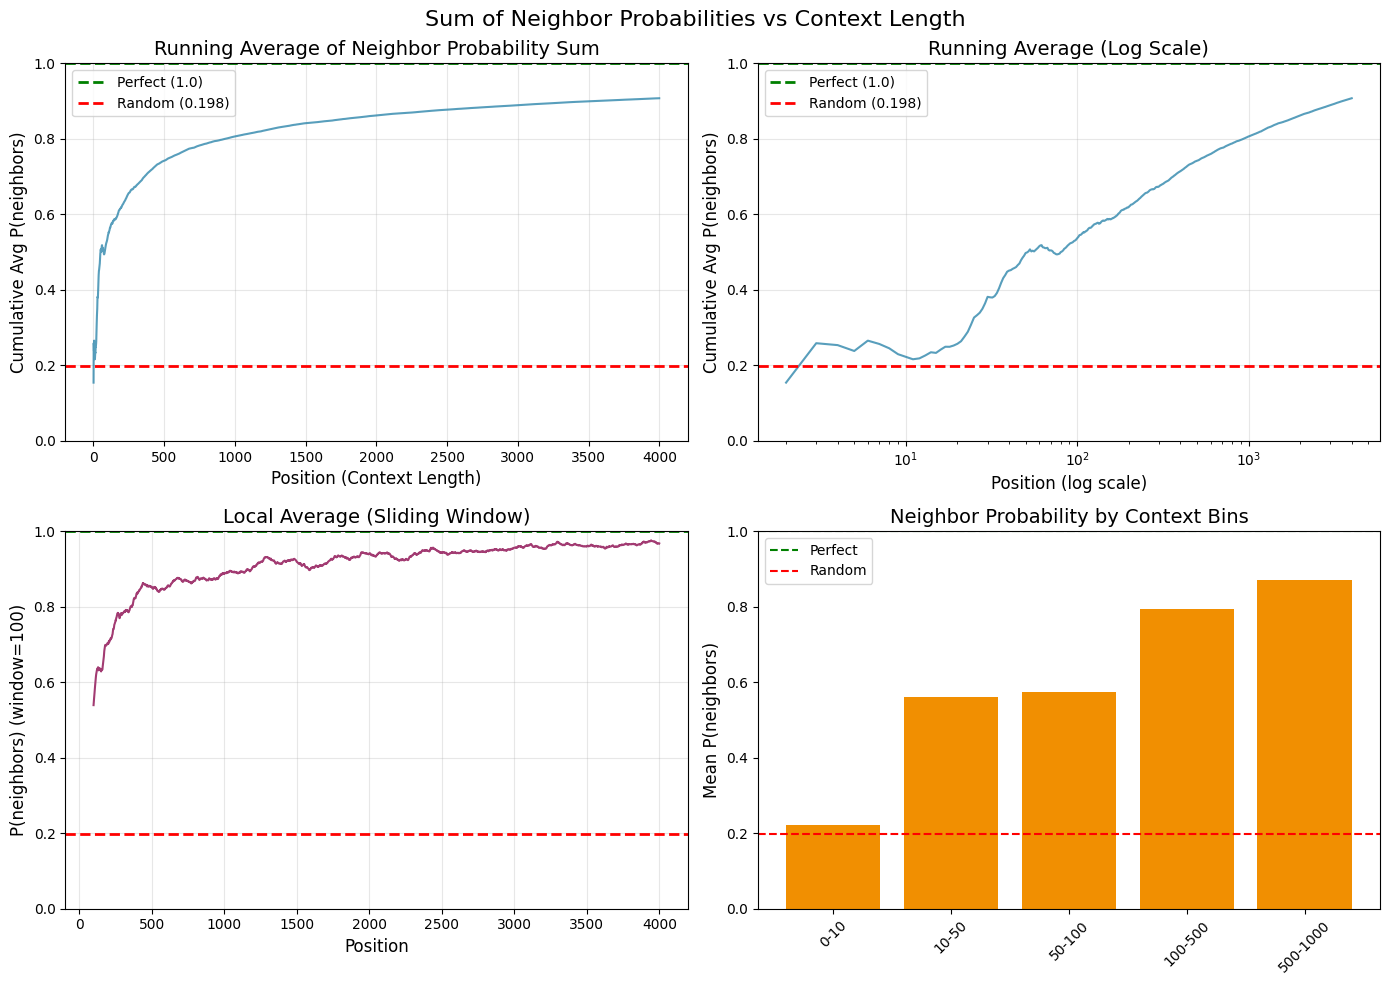


Final average P(neighbors): 0.9075
Random baseline (avg_neighbors/16): 0.1981
Average number of neighbors: 3.17


In [ ]:
# --- Plot neighbor probability vs context length ---

# Compute baselines
avg_neighbors = np.mean(neighbor_counts)
random_baseline = avg_neighbors / len(CONCEPTS)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Sum of Neighbor Probabilities vs Context Length', fontsize=16)

# Plot 1: Running average of neighbor probability
ax1 = axes[0, 0]
ax1.plot(positions, running_avg, linewidth=1.5, color='#2E86AB', alpha=0.8)
ax1.axhline(y=1.0, color='green', linestyle='--', linewidth=2, label='Perfect (1.0)')
ax1.axhline(y=random_baseline, color='red', linestyle='--', linewidth=2, label=f'Random ({random_baseline:.3f})')
ax1.set_xlabel('Position (Context Length)', fontsize=12)
ax1.set_ylabel('Cumulative Avg P(neighbors)', fontsize=12)
ax1.set_title('Running Average of Neighbor Probability Sum', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1)

# Plot 2: Log scale x-axis
ax2 = axes[0, 1]
ax2.semilogx(positions + 1, running_avg, linewidth=1.5, color='#2E86AB', alpha=0.8)
ax2.axhline(y=1.0, color='green', linestyle='--', linewidth=2, label='Perfect (1.0)')
ax2.axhline(y=random_baseline, color='red', linestyle='--', linewidth=2, label=f'Random ({random_baseline:.3f})')
ax2.set_xlabel('Position (log scale)', fontsize=12)
ax2.set_ylabel('Cumulative Avg P(neighbors)', fontsize=12)
ax2.set_title('Running Average (Log Scale)', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1)

# Plot 3: Sliding window average
window = 100
if len(neighbor_prob_sums) > window:
    slide_avg = np.convolve(neighbor_prob_sums, np.ones(window)/window, mode='valid')
    ax3 = axes[1, 0]
    ax3.plot(positions[window-1:], slide_avg, linewidth=1.5, color='#A23B72')
    ax3.axhline(y=1.0, color='green', linestyle='--', linewidth=2)
    ax3.axhline(y=random_baseline, color='red', linestyle='--', linewidth=2)
    ax3.set_xlabel('Position', fontsize=12)
    ax3.set_ylabel(f'P(neighbors) (window={window})', fontsize=12)
    ax3.set_title('Local Average (Sliding Window)', fontsize=14)
    ax3.grid(True, alpha=0.3)
    ax3.set_ylim(0, 1)

# Plot 4: Binned average neighbor probability
bins = [0, 10, 50, 100, 500, 1000, 5000]
bins = [b for b in bins if b <= max(positions)]
avgs, labels = [], []
for i in range(len(bins)-1):
    m = (positions >= bins[i]) & (positions < bins[i+1])
    if np.any(m):
        avgs.append(np.mean(neighbor_prob_sums[m]))
        labels.append(f'{bins[i]}-{bins[i+1]}')
ax4 = axes[1, 1]
ax4.bar(range(len(avgs)), avgs, color='#F18F01')
ax4.axhline(y=1.0, color='green', linestyle='--', label='Perfect')
ax4.axhline(y=random_baseline, color='red', linestyle='--', label='Random')
ax4.set_xticks(range(len(labels)))
ax4.set_xticklabels(labels, rotation=45)
ax4.set_ylabel('Mean P(neighbors)', fontsize=12)
ax4.set_title('Neighbor Probability by Context Bins', fontsize=14)
ax4.set_ylim(0, 1)
ax4.legend()

plt.tight_layout()
plt.show()

print(f"\nFinal average P(neighbors): {running_avg[-1]:.4f}")
print(f"Random baseline (avg_neighbors/16): {random_baseline:.4f}")
print(f"Average number of neighbors: {avg_neighbors:.2f}")


In [ ]:
# Create and test HMM
from src.hmm.hmm import Mess3HMM, belief_to_barycentric, belief_to_barycentric_evolution

# Initialize the HMM
hmm = Mess3HMM()

# Optionally create custom HMM with parameters (from epsilon transformers)
hmm.create_hmm(x=0.05, alpha=0.85)

# Generate sequences from the HMM
num_sequences = 1
seq_length = 4000
tokens, tokens_y = hmm.generate_dataset(num_sequences, seq_length)

print(f"Generated {num_sequences} sequences of length {seq_length}")
print(f"Tokens shape: {tokens.shape}")
print(f"Sample sequence: {tokens[0, :10].tolist()}")

# Compute belief states for the sequences
beliefs = hmm.compute_belief_state(tokens)
print(f"\nBelief states shape: {beliefs.shape}")
print(f"Sample belief state: {beliefs[0, 5].tolist()}")


Generated 1 sequences of length 4000
Tokens shape: torch.Size([1, 4000])
Sample sequence: [0, 1, 0, 0, 1, 0, 0, 0, 0, 2]

Belief states shape: torch.Size([1, 4001, 3])
Sample belief state: [0.4994296729564667, 0.4217967689037323, 0.07877356559038162]


In [ ]:
# Visualize belief states on the simplex
# belief_to_barycentric plots beliefs as points colored by their state
belief_to_barycentric(beliefs[:, -1].cpu(), beliefs[:, -1].cpu())

# Visualize belief state evolution over time (traces movement on simplex)
# belief_to_barycentric_evolution(beliefs[:10], beliefs[:10])


In [ ]:
tokens[0]

tensor([0, 1, 0,  ..., 2, 2, 2], device='cuda:0')